# Machine Learning for Time Series Forecasting

Classical models like ARIMA are powerful but limited to linear relationships. ML models can capture **non-linear patterns**, handle **many features**, and scale to **large datasets**.

## The Core Idea: Supervised Learning Framing

Transform time series forecasting into a standard supervised learning problem:

$$\hat{y}_{t+h} = f(y_t, y_{t-1}, \ldots, y_{t-p}, \mathbf{x}_t)$$

where $\mathbf{x}_t$ are engineered features (date features, rolling stats, etc.) and $f$ is any ML model.

## Key Difference from Classical Methods
| Classical | ML |
|-----------|----|
| Explicit model of autocorrelation | Implicit via lag features |
| One series at a time | Can handle thousands simultaneously |
| Linear (ARIMA) | Non-linear |
| Few parameters | Many parameters |
| Strong theoretical basis | Empirically driven |

                   time  passengers
1949-01-01  1949.000000         112
1949-02-01  1949.083333         118
1949-03-01  1949.166667         132
1949-04-01  1949.250000         129
1949-05-01  1949.333333         121


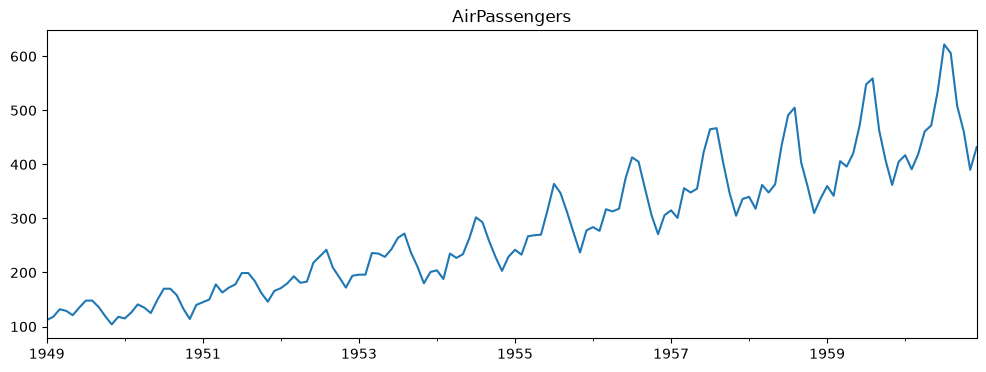

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import TimeSeriesSplit

# AirPassengers dataset
from statsmodels.datasets import get_rdataset
data = get_rdataset('AirPassengers').data
data.index = pd.date_range(start='1949-01', periods=len(data), freq='MS')
df = data.rename(columns={'value': 'passengers'})

print(df.head())
df['passengers'].plot(figsize=(12,4), title='AirPassengers')
plt.show()

## Feature Engineering for Time Series

Feature engineering is the **most important step** when using ML for forecasting.

### 1. Lag Features
$$X^{(k)}_t = y_{t-k}$$

### 2. Rolling / Window Statistics
$$\text{roll\_mean}^{(k)}_t = \frac{1}{k}\sum_{i=1}^{k} y_{t-i}$$
$$\text{roll\_std}^{(k)}_t = \sqrt{\frac{1}{k}\sum_{i=1}^{k}(y_{t-i} - \text{roll\_mean}^{(k)}_t)^2}$$

### 3. Date/Calendar Features
- Month, quarter, day of week, week of year
- Is weekend, is holiday
- Cyclical encoding: $\sin\left(\frac{2\pi t}{T}\right)$, $\cos\left(\frac{2\pi t}{T}\right)$

### 4. Expanding Window Statistics
$$\text{expand\_mean}_t = \frac{1}{t}\sum_{i=1}^{t} y_i$$

### 5. Difference Features
$$\Delta^{(k)}_t = y_t - y_{t-k}$$

In [2]:
def create_features(df, target='passengers', lags=[1,2,3,6,12], windows=[3,6,12]):
    df = df.copy()
    
    # Lag features
    for lag in lags:
        df[f'lag_{lag}'] = df[target].shift(lag)
    
    # Rolling statistics
    for w in windows:
        df[f'roll_mean_{w}'] = df[target].shift(1).rolling(w).mean()
        df[f'roll_std_{w}']  = df[target].shift(1).rolling(w).std()
        df[f'roll_max_{w}']  = df[target].shift(1).rolling(w).max()
        df[f'roll_min_{w}']  = df[target].shift(1).rolling(w).min()
    
    # Expanding mean
    df['expanding_mean'] = df[target].shift(1).expanding().mean()
    
    # Difference features
    df['diff_1']  = df[target].shift(1).diff(1)
    df['diff_12'] = df[target].shift(1).diff(12)
    
    # Date features
    df['month']   = df.index.month
    df['quarter'] = df.index.quarter
    df['year']    = df.index.year
    
    # Cyclical month encoding
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
    
    return df

df_feat = create_features(df)
df_feat = df_feat.dropna()

print(f"Features created: {df_feat.shape[1] - 1} features")
print(df_feat.columns.tolist())

Features created: 26 features
['time', 'passengers', 'lag_1', 'lag_2', 'lag_3', 'lag_6', 'lag_12', 'roll_mean_3', 'roll_std_3', 'roll_max_3', 'roll_min_3', 'roll_mean_6', 'roll_std_6', 'roll_max_6', 'roll_min_6', 'roll_mean_12', 'roll_std_12', 'roll_max_12', 'roll_min_12', 'expanding_mean', 'diff_1', 'diff_12', 'month', 'quarter', 'year', 'month_sin', 'month_cos']


## Time Series Cross-Validation

Standard k-fold CV is **wrong** for time series (it leaks future data into training).

### TimeSeriesSplit (Expanding Window)
```
Fold 1: Train [t1...t100]      Test [t101...t110]
Fold 2: Train [t1...t110]      Test [t111...t120]
Fold 3: Train [t1...t120]      Test [t121...t130]
```

### Walk-Forward (Sliding Window)
```
Fold 1: Train [t1...t100]      Test [t101...t110]
Fold 2: Train [t11...t110]     Test [t111...t120]
Fold 3: Train [t21...t120]     Test [t121...t130]
```

**Rule:** The test set always comes **after** the training set in time.

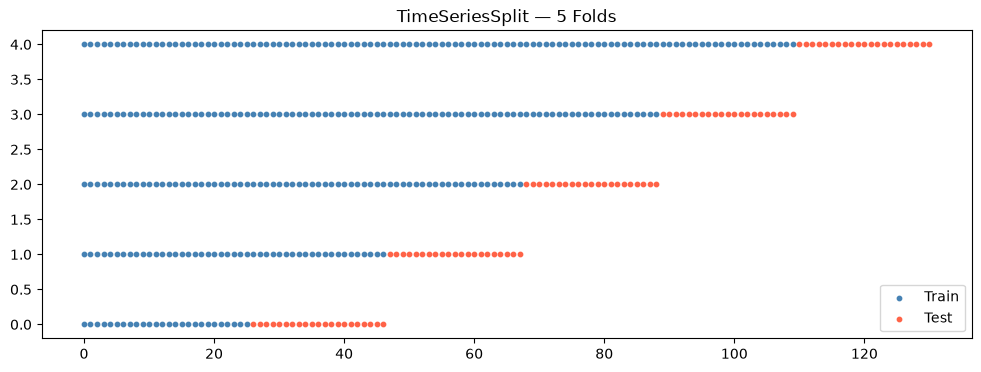

In [3]:
X = df_feat.drop('passengers', axis=1)
y = df_feat['passengers']

# Visual of TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=5)
fig, ax = plt.subplots(figsize=(12, 4))
for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
    ax.scatter(train_idx, [fold] * len(train_idx), c='steelblue', s=10, label='Train' if fold == 0 else '')
    ax.scatter(test_idx,  [fold] * len(test_idx),  c='tomato',   s=10, label='Test'  if fold == 0 else '')
ax.set_title('TimeSeriesSplit 5 Folds')
ax.legend()
plt.show()

## Random Forest for Forecasting

Random Forest: MAE=39.29, MAPE=7.98%


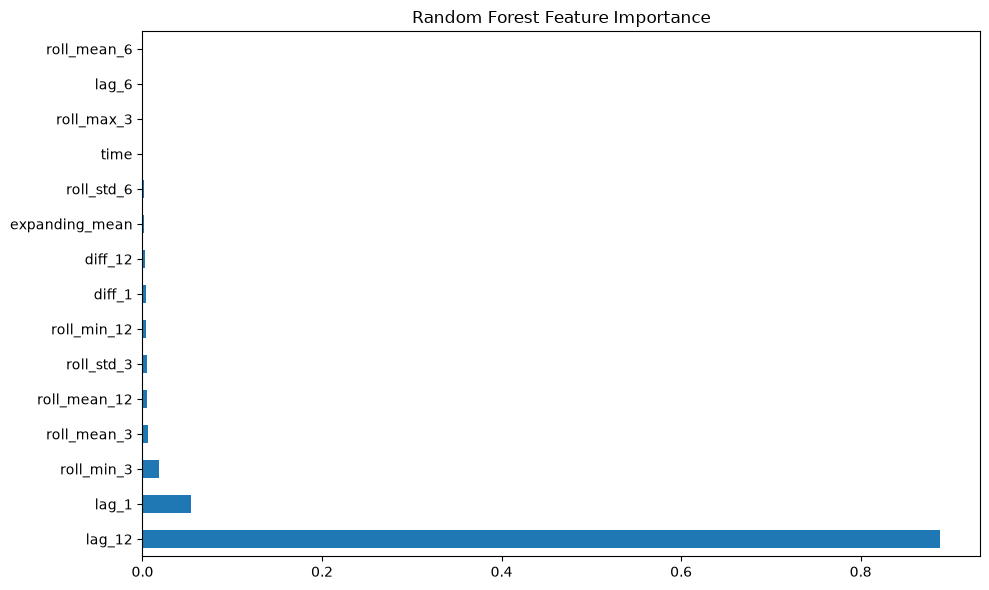

In [4]:
# Train/test split (last 24 months = test)
split = -24
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

# Random Forest
rf = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

mae_rf  = mean_absolute_error(y_test, y_pred_rf)
mape_rf = np.mean(np.abs((y_test.values - y_pred_rf) / y_test.values)) * 100
print(f"Random Forest: MAE={mae_rf:.2f}, MAPE={mape_rf:.2f}%")

# Feature importance
feat_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
feat_imp.head(15).plot(kind='barh', figsize=(10,6), title='Random Forest Feature Importance')
plt.tight_layout()
plt.show()

## XGBoost / LightGBM for Forecasting

Gradient boosting models are state-of-the-art for tabular/feature-based forecasting.

The boosting objective minimises:
$$\mathcal{L} = \sum_{i=1}^{n} l(y_i, \hat{y}_i) + \sum_{k=1}^{K} \Omega(f_k)$$

where $\Omega(f) = \gamma T + \frac{1}{2}\lambda \|w\|^2$ is the regularisation term.

In [5]:
try:
    import xgboost as xgb
    import lightgbm as lgb
    
    # XGBoost
    xgb_model = xgb.XGBRegressor(n_estimators=300, learning_rate=0.05,
                                   max_depth=5, subsample=0.8,
                                   colsample_bytree=0.8, random_state=42)
    xgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
    y_pred_xgb = xgb_model.predict(X_test)
    
    # LightGBM
    lgb_model = lgb.LGBMRegressor(n_estimators=300, learning_rate=0.05,
                                   num_leaves=31, random_state=42)
    lgb_model.fit(X_train, y_train)
    y_pred_lgb = lgb_model.predict(X_test)
    
    for name, pred in [('XGBoost', y_pred_xgb), ('LightGBM', y_pred_lgb)]:
        mae  = mean_absolute_error(y_test, pred)
        mape = np.mean(np.abs((y_test.values - pred) / y_test.values)) * 100
        print(f"{name:10s}: MAE={mae:.2f}, MAPE={mape:.2f}%")

except ImportError:
    print("Install: pip install xgboost lightgbm")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003717 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 714
[LightGBM] [Info] Number of data points in the train set: 107, number of used features: 26
[LightGBM] [Info] Start training from score 260.504673
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

## Multi-Step Forecasting Strategies

### 1. Recursive (One-Step-Ahead)
Train one model, forecast one step, use that prediction as input for the next step.
$$\hat{y}_{t+1} = f(y_t, y_{t-1}, \ldots)$$
$$\hat{y}_{t+2} = f(\hat{y}_{t+1}, y_t, \ldots)$$
**Risk:** error accumulates over horizon.

### 2. Direct
Train a **separate model** for each forecast horizon $h$:
$$\hat{y}_{t+h} = f_h(y_t, y_{t-1}, \ldots)$$
**Advantage:** no error accumulation. **Disadvantage:** $H$ separate models.

### 3. MIMO (Multi-Input Multi-Output)
Single model that directly outputs all $H$ forecasts simultaneously.

In [6]:
# Recursive multi-step forecast
def recursive_forecast(model, X_last, n_steps, feature_cols):
    """Recursively generate forecasts for demonstration."""
    forecasts = []
    current = X_last.copy()
    
    for _ in range(n_steps):
        pred = model.predict(current.values.reshape(1, -1))[0]
        forecasts.append(pred)
        # In practice, update lag features with predicted value
        # This is simplified real implementation shifts lag columns
    
    return forecasts

print("Multi-step strategies: Direct vs Recursive")
print("Direct:    train H separate models, one per horizon")
print("Recursive: train 1 model, feed predictions back as features")
print("MIMO:      train 1 model with H outputs simultaneously")

Multi-step strategies: Direct vs Recursive
Direct:    train H separate models, one per horizon
Recursive: train 1 model, feed predictions back as features
MIMO:      train 1 model with H outputs simultaneously


## Forecast Comparison

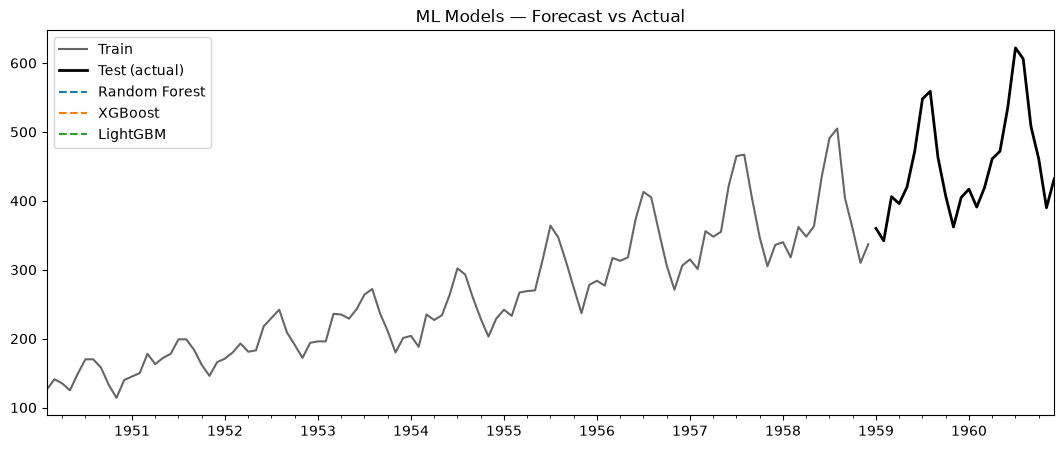

In [7]:
fig, ax = plt.subplots(figsize=(13, 5))
y_train.plot(ax=ax, label='Train', color='black', alpha=0.6)
y_test.plot(ax=ax, label='Test (actual)', color='black', linewidth=2)
ax.plot(y_test.index, y_pred_rf, label='Random Forest', linestyle='--')
try:
    ax.plot(y_test.index, y_pred_xgb, label='XGBoost', linestyle='--')
    ax.plot(y_test.index, y_pred_lgb, label='LightGBM', linestyle='--')
except:
    pass
ax.set_title('ML Models Forecast vs Actual')
ax.legend()
plt.show()

## Global vs Local Models

| Model Type | Description | Use Case |
|------------|-------------|----------|
| **Local** | Separate model per series (ARIMA, ETS) | Few series, high accuracy needed |
| **Global** | One model across all series (LightGBM, LSTM) | Many similar series |
| **Hybrid** | Global model + local residual correction | Best of both worlds |

Global models can **transfer patterns** across series and handle **cold-start** problems.

---

## Additional Learning Resources

### Papers
- Makridakis et al. (2022) M5 Competition: https://www.sciencedirect.com/science/article/pii/S0169207021001874
- Cerqueira et al. (2020) Evaluating time series forecasting models: https://arxiv.org/abs/1905.11744
- Godahewa et al. (2021) Monash Time Series Forecasting Archive: https://arxiv.org/abs/2105.06643

### Libraries
- sktime: https://www.sktime.net/en/stable/
- Nixtla StatsForecast: https://nixtlaverse.nixtla.io/statsforecast/
- Feature-engine time series: https://feature-engine.trainindata.com/en/latest/

### Kaggle Competitions
- M5 Forecasting Accuracy: https://www.kaggle.com/c/m5-forecasting-accuracy
- Store Sales Time Series Forecasting: https://www.kaggle.com/c/store-sales-time-series-forecasting

### Books
- Hands-On Time Series Analysis with Python Boris Lyssenko
- Practical Time Series Analysis Aileen Nielsen